## Resampling of Yearly LULC Data

The original 300 m resolution land cover classification maps (1992–present) were resampled to a 25 km grid to match the spatial resolution of the TB_diff data. Although large year-to-year variations in LULC are not expected, annual resampling was performed to enable year-specific masking and to ensure temporal consistency with the analysis.

The original 300 m resolution dataset is available from the Copernicus Climate Data Store:
https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview

In [5]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pdL
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Create the land mask for regions north of 60°N

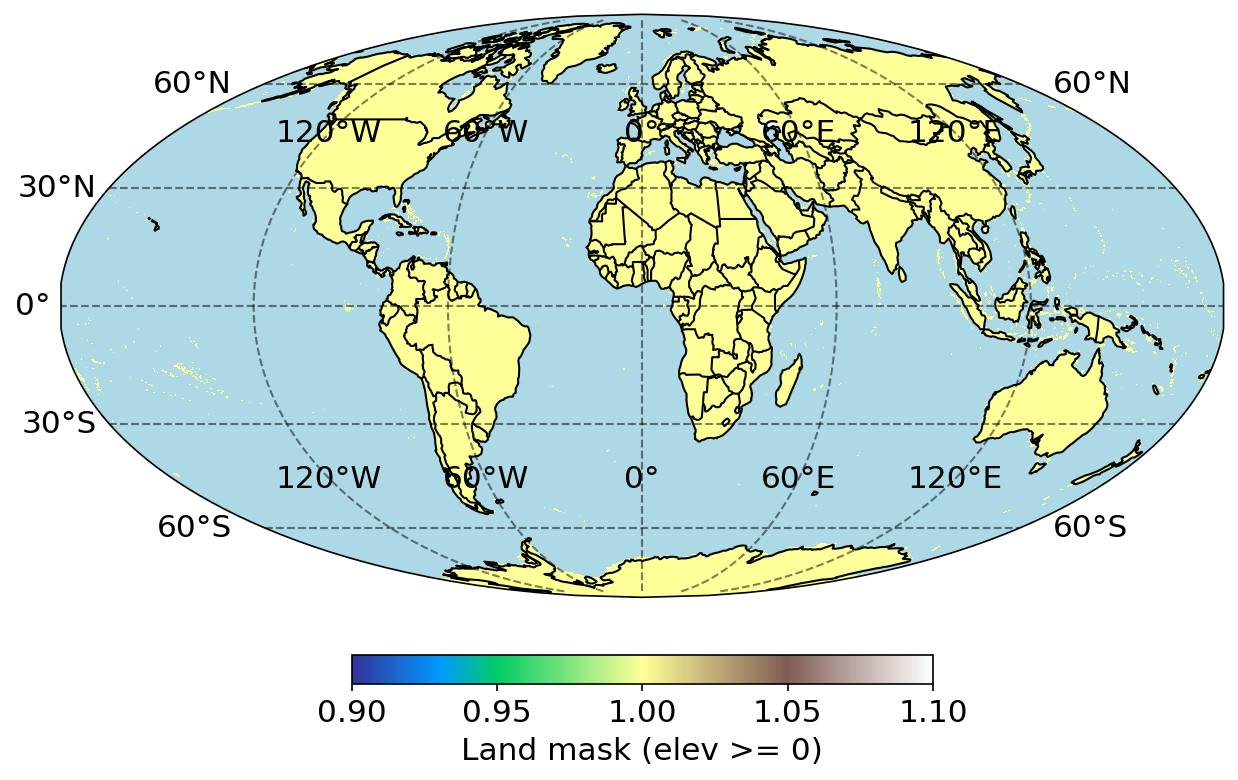

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Check the downloaded original LULC data

In [3]:
LULC_path = '/home/nayoung/nas_data/LULC/ESA_CCI'

# Find out if there's nc files in the directory
nc_files = sorted([f for f in os.listdir(LULC_path) if f.endswith('.nc')])
print("NC file lists: ", nc_files)

# Check the arbitary nc file, to check the variable names and shapes
with nc.Dataset(os.path.join(LULC_path, nc_files[0])) as ds:
    print(ds.variables.keys())
    lccs_class = ds.variables['lccs_class'][:]

print(lccs_class.shape) # (time, lat, lon) -> single time step

NC file lists:  ['C3S-LC-L4-LCCS-Map-300m-P1Y-2016-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2017-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2018-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2019-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2020-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2021-v2.1.1.nc', 'C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1995-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1996-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1997-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1998-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1999-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-2000-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-2001-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-2002-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-2003-v2.0.7cds.nc', 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-2004-

## Resampling of LULC Data

The original 300 m resolution data were resampled to a 25 km grid. To improve computational efficiency and reduce memory usage, the latitude domain was first restricted to 59°N, followed by resampling and subsequent cropping to regions north of 60°N. 
Because LULC is a categorical variable, applying a mean during resampling would distort class labels. Therefore, mode aggregation was used to preserve the dominant land cover type within each grid cell.

In [4]:
LULC_path = '/home/nayoung/nas_data/LULC/ESA_CCI'
output_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC'
os.makedirs(output_path, exist_ok=True)

# Create the target 25km grid
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)  # (720,1440) 

# To improve resampling accuracy, data north of 59°N were first included in the resampling process, and only grid cells north of 60°N were retained afterward.
row_idx = np.where(domain_lat[:, 0] >= 59.0)[0]
domain_lat = domain_lat[row_idx, :]
domain_lon = domain_lon[row_idx, :]
print(domain_lat.shape)  # (124, 1440)
print(domain_lon.shape)  # (124, 1440)

# Set the start and end years
start_year = 1992
end_year   = 2022

stack_list = []

for year in range(start_year, end_year + 1):
    for fname in os.listdir(LULC_path):
        if str(year) in fname and fname.endswith('.nc'):
            LULC_file = os.path.join(LULC_path, fname)
            print(f"Opening year {year} file: {LULC_file}")

            with nc.Dataset(LULC_file) as ds:
                print(ds.variables.keys())
                lat = ds.variables['lat'][:]        
                lon = ds.variables['lon'][:]        

                # Choose the latitude above 59N
                lat_idx  = np.where(lat >= 59.0)[0]
                lat_sel  = lat[lat_idx]  

                # Read the LULC
                LULC = ds.variables['lccs_class'][:]
                if LULC.ndim == 3:
                    LULC = LULC[0, :, :]           
                LULC = LULC[lat_idx, :]            

            print(np.shape(lat_sel))  
            print(np.shape(lon))      
            print(np.shape(LULC))    

            # Create the original 2D coordinates
            original_lon_2d, original_lat_2d = np.meshgrid(lon, lat_sel)

            # Resample to 25km (the target is already cut above 59N → (124,1440))
            LULC_25km = hData.Resampling(
                domain_lon, domain_lat,
                original_lon_2d, original_lat_2d, LULC,
                sampling_method='nearest', agg_method='mode', mag_factor=2 # Mode aggregation was applied to LULC because it is categorical
            )
            print(np.shape(LULC_25km))  # (124, 1440)

            # Cut the latitude above 60N
            row_60 = np.where(domain_lat[:, 0] >= 60.0)[0]
            LULC_25km = LULC_25km[row_60, :]
            print(np.shape(LULC_25km))

            # Stack the year
            stack_list.append(LULC_25km.astype(np.int16))

# Stack the year to the time axis: (lat, lon, time)
LULC_3D = np.stack(stack_list, axis=2)  # (124, 1440, 31)
dictionary = {'lccs_class': LULC_3D}

(124, 1440)
(124, 1440)
Opening year 1992 file: /home/nayoung/nas_data/LULC/ESA_CCI/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.nc
dict_keys(['lccs_class', 'processed_flag', 'current_pixel_state', 'observation_count', 'change_count', 'lat', 'lon', 'crs', 'lat_bounds', 'lon_bounds', 'time_bounds', 'time'])
(11160,)
(129600,)
(11160, 129600)
(124, 1440)
(120, 1440)
Opening year 1993 file: /home/nayoung/nas_data/LULC/ESA_CCI/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.nc
dict_keys(['lccs_class', 'processed_flag', 'current_pixel_state', 'observation_count', 'change_count', 'lat', 'lon', 'crs', 'lat_bounds', 'lon_bounds', 'time_bounds', 'time'])
(11160,)
(129600,)
(11160, 129600)
(124, 1440)
(120, 1440)
Opening year 1994 file: /home/nayoung/nas_data/LULC/ESA_CCI/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.nc
dict_keys(['lccs_class', 'processed_flag', 'current_pixel_state', 'observation_count', 'change_count', 'lat', 'lon', 'crs', 'lat_bounds', 'lon_bounds', 'time_bounds', 'time'])
(11

In [5]:
# Set the target grid (north of 60N)
domain_lon_25, domain_lat_25 = hGrid.generate_lon_lat_eqdgrid(0.25)  # (720,1440)
row60 = np.where(domain_lat_25[:, 0] >= 60.0)[0]
domain_lat_25 = domain_lat_25[row60, :]         # (120,1440)
domain_lon_25 = domain_lon_25[row60, :]

# Expand the 2D land mask to 3D for broadcasting over the time dimension (to save each year's data to the same file)
assert land_mask_60N_base.shape == domain_lat_25.shape == domain_lon_25.shape
mask3d = land_mask_60N_base.astype(bool)[..., None]   # (120,1440,1) -> broadcast to (120,1440,31)

for name, arr in dictionary.items():  # arr: (120,1440,31)
    assert arr.shape[:2] == land_mask_60N_base.shape, f"{name} shape mismatch"
    dictionary[name] = np.where(mask3d, arr, np.nan).astype('f4')

years = np.arange(start_year, end_year + 1, dtype=np.int32)
ny, nx, nt = next(iter(dictionary.values())).shape
assert (ny, nx, nt) == (domain_lat_25.shape[0], domain_lat_25.shape[1], len(years))

# Save
out_nc = os.path.join(output_path, 'ESA_CCI_LULC_25km_60N_1992_2022.nc')
with nc.Dataset(out_nc, 'w', format='NETCDF4') as dst:
    # dims
    dst.createDimension('lat',  ny)
    dst.createDimension('lon',  nx)
    dst.createDimension('time', nt)

    # coords (2D lat/lon)
    vlat  = dst.createVariable('lat',  'f4', ('lat','lon'))
    vlon  = dst.createVariable('lon',  'f4', ('lat','lon'))
    vtime = dst.createVariable('time', 'i4', ('time',))
    vlat[:]  = domain_lat_25; vlat.units  = 'degrees_north'; vlat.standard_name = 'latitude'
    vlon[:]  = domain_lon_25; vlon.units  = 'degrees_east';  vlon.standard_name = 'longitude'
    vtime[:] = np.arange(nt, dtype=np.int32)
    vtime.units = 'years since 1992-01-01 00:00:00'

    # data vars 
    for name, arr in dictionary.items():  # arr: (120,1440,31), dtype float32 with NaN
        var = dst.createVariable(
            name, 'f4', ('lat','lon','time'),
            zlib=True, complevel=4, chunksizes=(60, 360, 1),
            fill_value=np.float32(np.nan)  # NaN fill
        )
        var.long_name  = name
        var.coordinates = 'lat lon'
        var[:, :, :] = arr

# Check
with nc.Dataset(out_nc) as ds:
    print('saved vars:', list(ds.variables.keys()))
    for k in dictionary.keys():
        print(k, ds[k].dtype, ds[k].shape)

saved vars: ['lat', 'lon', 'time', 'lccs_class']
lccs_class float32 (120, 1440, 31)


## Validation of Resampled LULC Data

The original and resampled LULC datasets for the same year are compared to assess whether the resampling process reliably preserves the key spatial patterns and characteristics of the original dataset.

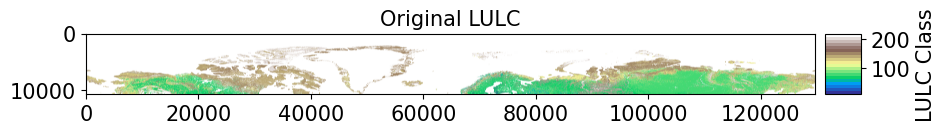

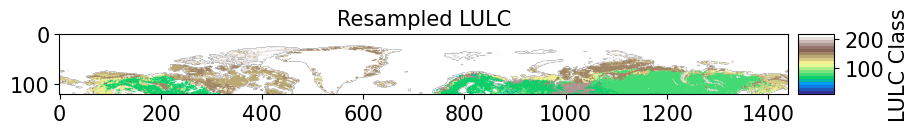

In [6]:
# Compare for the same year (1992)
Original_LULC_path = '/home/nayoung/nas_data/LULC/ESA_CCI/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.nc'
Resampled_LULC_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/ESA_CCI_LULC_25km_60N_1992_2022.nc'

# Load the original LULC data
with nc.Dataset(Original_LULC_path) as ds:
    lat = ds.variables['lat'][:]
    lon = ds.variables['lon'][:]
    Original_1992_LULC = ds.variables['lccs_class'][0, :, :] # (time, lat, lon) = (1, 64800, 129600) -> (64800, 129600)

lat_mask = lat >= 60
lat_idx = np.where(lat_mask)[0]
Original_1992_60N_LULC = Original_1992_LULC[lat_idx, :] # (10800, 129600)

# Load the resampled LULC data
with nc.Dataset(Resampled_LULC_path) as ds:
    Resampled_LULC = ds.variables['lccs_class'][:] # (lat, lon, time) = (120, 1440, 31)
    Resampled_1992_60N_LULC = Resampled_LULC[:, :, 0] # (120, 1440)

# Compare the two datasets (Due to the high memory requirements of the original 300 m resolution data, generating the NorthPole plot is not feasible in this case)
def plot_lulc(data, title):
    fig, ax = plt.subplots(figsize=(10, 10))
    cmap = plt.cm.get_cmap('terrain', 20) 
    
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1) 
    
    plt.colorbar(im, cax=cax, label='LULC Class')
    plt.show()

plot_lulc(Original_1992_60N_LULC, 'Original LULC')
plot_lulc(Resampled_1992_60N_LULC, 'Resampled LULC')
